In [ ]:
import math

from plotnine import *
import pandas as pd


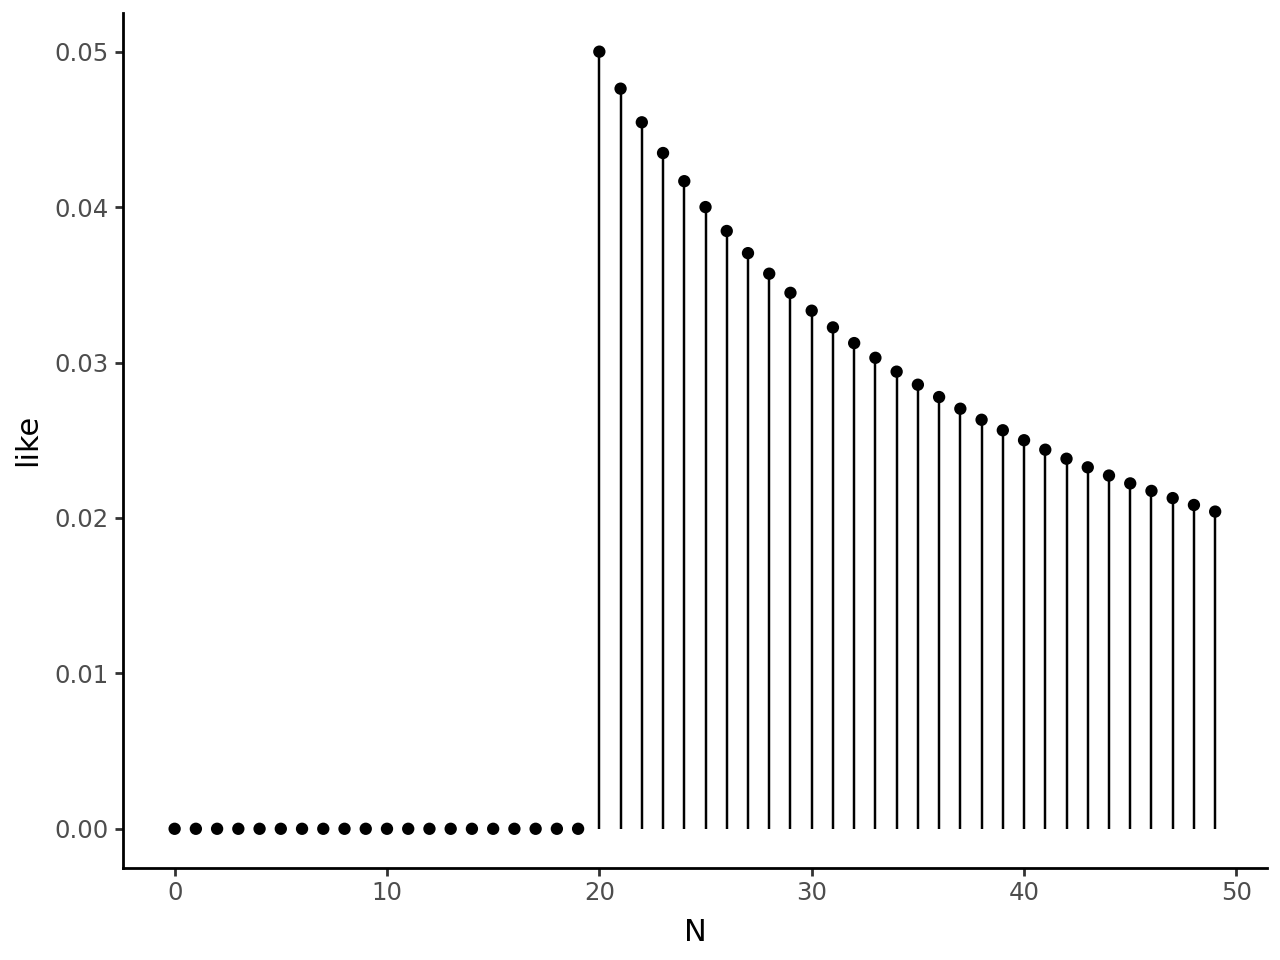

In [28]:
#likelihood function for 1 observation
#P(x1|N) = if N>=x1: 1/N, else 0
sample = 20
idxs= [i for i in range(50)]
lhoods = [0 if i<sample else 1/i for i in range(50)]
a = pd.DataFrame({"N":idxs,"like":lhoods})

(ggplot(a,aes("N", "like")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "like")) +
  theme_classic()
)

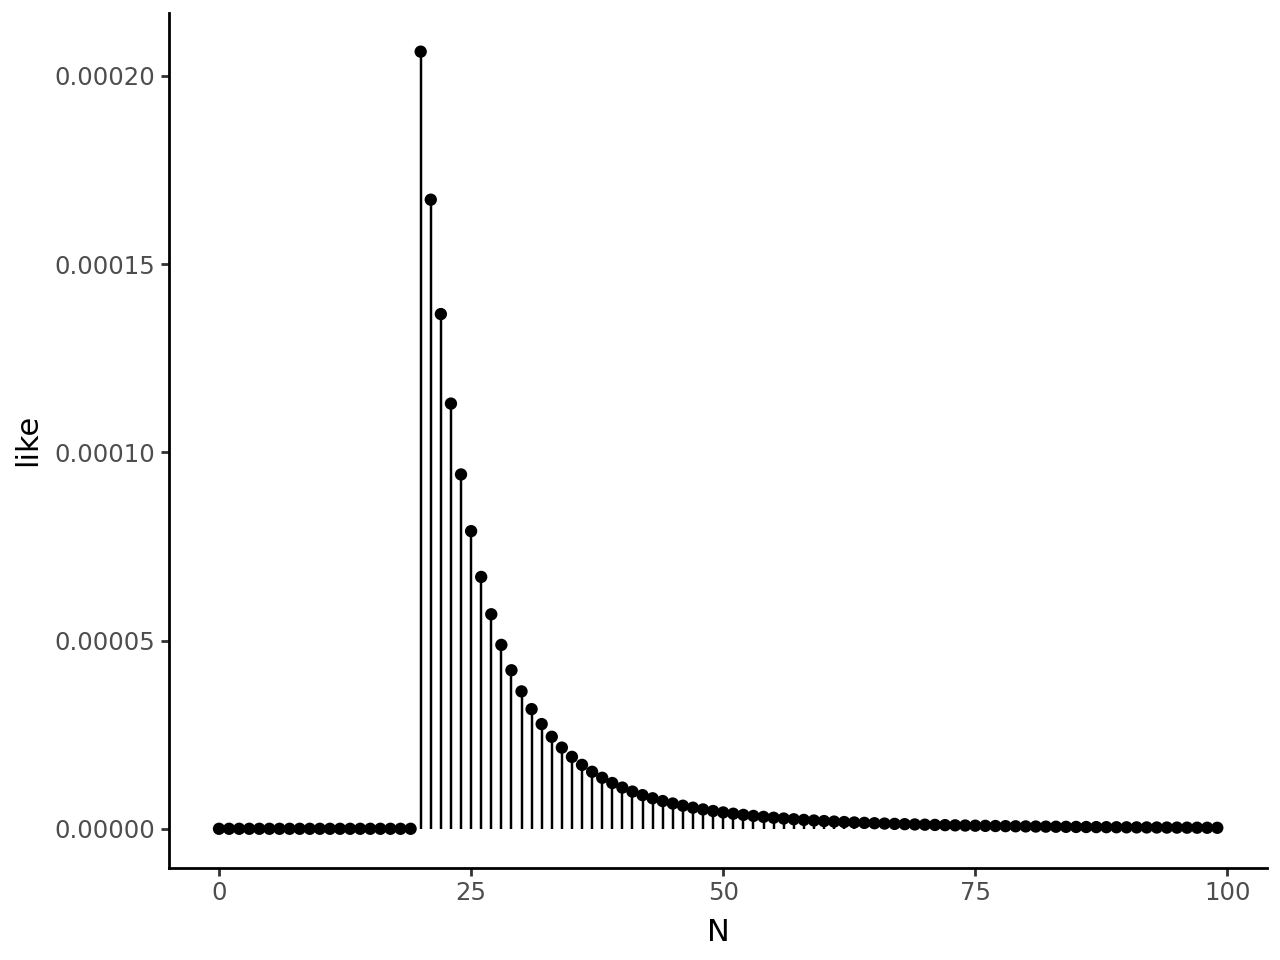

In [44]:
#multiple observations
#P(x1,x2....xn|N) = if N>=x1: 1/(math.comb(n, k)), else 0

samples = [17,20,16,19]

idxs= [i for i in range(100)]
lhoods = [0 if i<max(samples) else 1/math.comb(i, len(samples)) for i in idxs]
a = pd.DataFrame({"N":idxs,"like":lhoods})

(ggplot(a,aes("N", "like")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "like")) +
  theme_classic()
)


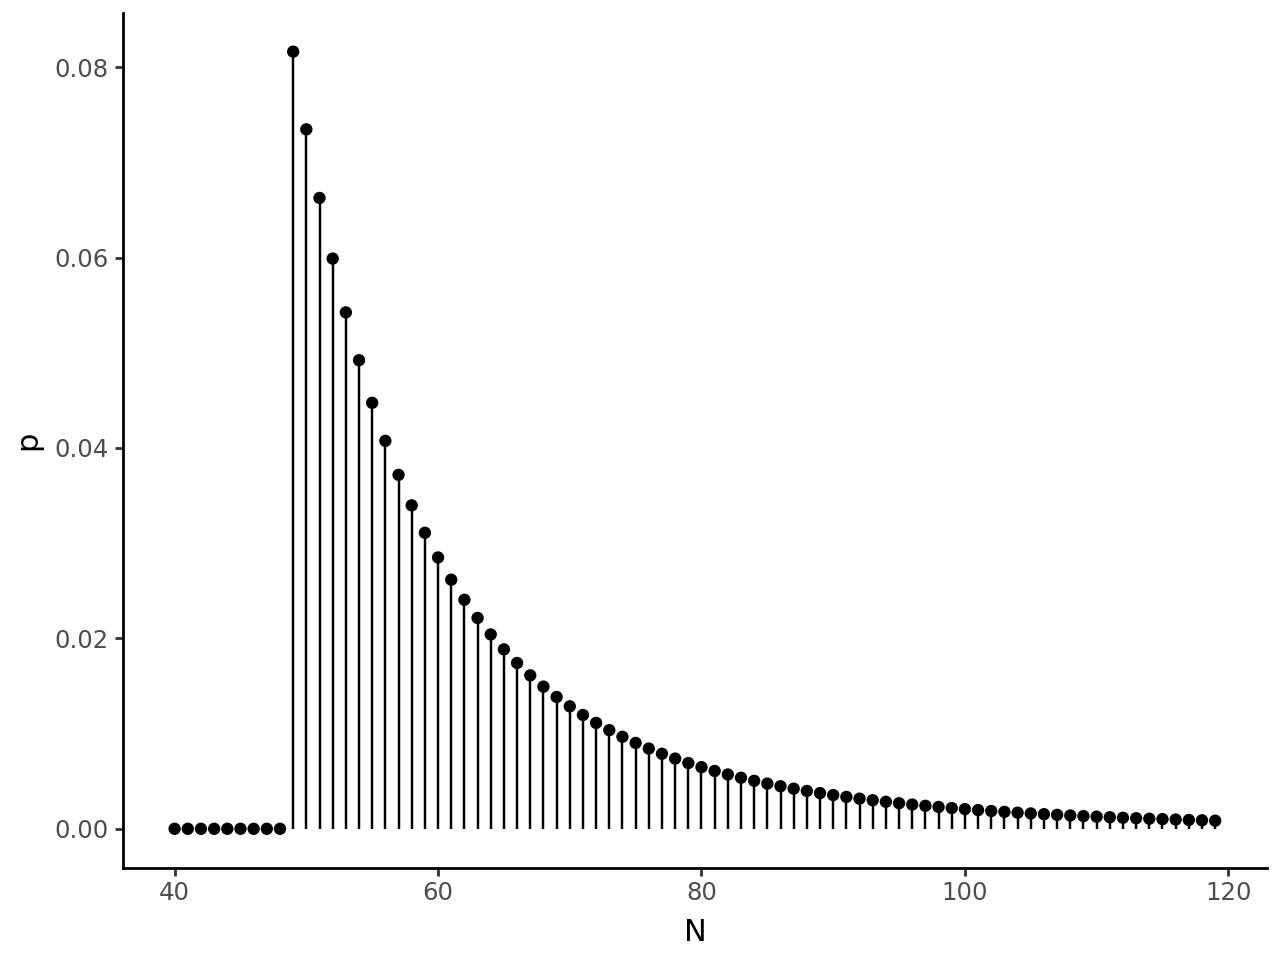

In [61]:
#probability density function
#

def dgtp(N:int,x:list[int]):
    """ 
    Probability mass function for the german tank problem
    
    (Andrews, Mark. 2021. “German Tank Problem: A Bayesian Analysis.” July 16, 2021. https://www.mjandrews.org/notes/germantank/.)

    "Note that we calculate the numerator and denominator using logarithms, which can avoid numerical overflow when calculating binomial coefficients."
    """
    n = len(x)
    m = max(x)
    # log of denominator (marginal likelihood)
    logZ = - math.log(math.comb(m,n)) + math.log(m) - math.log(n-1)

    if N < m:
        p = 0
    else:
        p = math.exp( -math.log(math.comb(N,n)) - logZ)
    return p

samples = [49, 28, 12, 19, 16]

idxs= [i for i in range(40,120)]
p_vals = [dgtp(i,samples) for i in idxs]
a = pd.DataFrame({"N":idxs,"p":p_vals})

(ggplot(a,aes("N", "p")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "p")) +
  theme_classic()
)


In [69]:
def gtp_median(x:list[int]):
    """
    Finds the median of the German Tank Problem density mass for values x1...xn
    """

    m = max(x)
    s = dgtp(m, x)
    i = m
    while (s + dgtp(i + 1, x) < 0.5):
        i = i + 1
        s = s + dgtp(i, x)
    return i
  
def gtp_hdp(x:list[int], p = 0.95):
    """
    Finds high posterior density interval.

    "any value of N in this interval has a higher posterior probability than any value of N outside this interval"
    """
    m = max(x)
    s = dgtp(m,x)
    i = m
    while (s + dgtp(i + 1, x) < p):
        i = i + 1
        s = s + dgtp(i, x)

    return m, i


In [71]:
gtp_hdp(samples, p=.8)

(49, 71)

In [101]:
#get alien data
a_df = pd.read_csv("../data/AlienData.csv", dtype="object")
rule_ids = pd.read_csv("../data/rule_ids.csv", dtype = "object")

In [ ]:
#separate training and test

#separate by unique_id
#assert rule id is len(1)
#separate by "rule_num"
#look at last 8 correct, should all be 1

In [216]:
#turn cols to float
a_df["points"] = [float(i) for i  in a_df["points"]]
a_df["correct"] = [float(i) for i  in a_df["correct"]]
#group by the interesting vars, take last 8 rows, check if all of them were correct
a_corrs = a_df.groupby(['unique_id', "condition", 'block', "rule_id", "rule_num"]).tail(8).groupby(['unique_id', "condition", 'block', "rule_id", "rule_num"]).agg(
    win = ("correct","mean")
).reset_index()

#get turn numbers
a_turns = a_df.groupby(['unique_id', "condition", 'block', "rule_id", "rule_num"]).agg(
    turns = ('correct', 'count'),
).reset_index()

#append
a_turns["win"] = a_corrs["win"]


In [226]:
a_wins = a_turns[a_turns["win"]==1]
a_wins = a_wins[a_wins["block"]=="test"]

In [244]:
#rule ids
rule_01 =list(a_wins[a_wins["rule_id"] == "01"]["turns"])
rule_02 =list(a_wins[a_wins["rule_id"] == "02"]["turns"])
rule_03 =list(a_wins[a_wins["rule_id"] == "03"]["turns"])
rule_04 =list(a_wins[a_wins["rule_id"] == "04"]["turns"])
rule_05 =list(a_wins[a_wins["rule_id"] == "05"]["turns"])

,unique_id,condition,block,rule_id,rule_num,turns,win
4,1_11_1,1_I,test,01,2,97,1.0
5,1_11_1,1_I,test,01,3,55,1.0
7,1_11_1,1_I,test,01,5,16,1.0
10,1_12_2,1_I,test,02,2,93,1.0
11,1_12_2,1_I,test,02,3,120,1.0
...,...,...,...,...,...,...,...
814,3_7_1,3_D,test,02,6,18,1.0
823,3_9_1,3_D,test,04,2,21,1.0
825,3_9_1,3_D,test,04,4,48,1.0
826,3_9_1,3_D,test,04,5,29,1.0


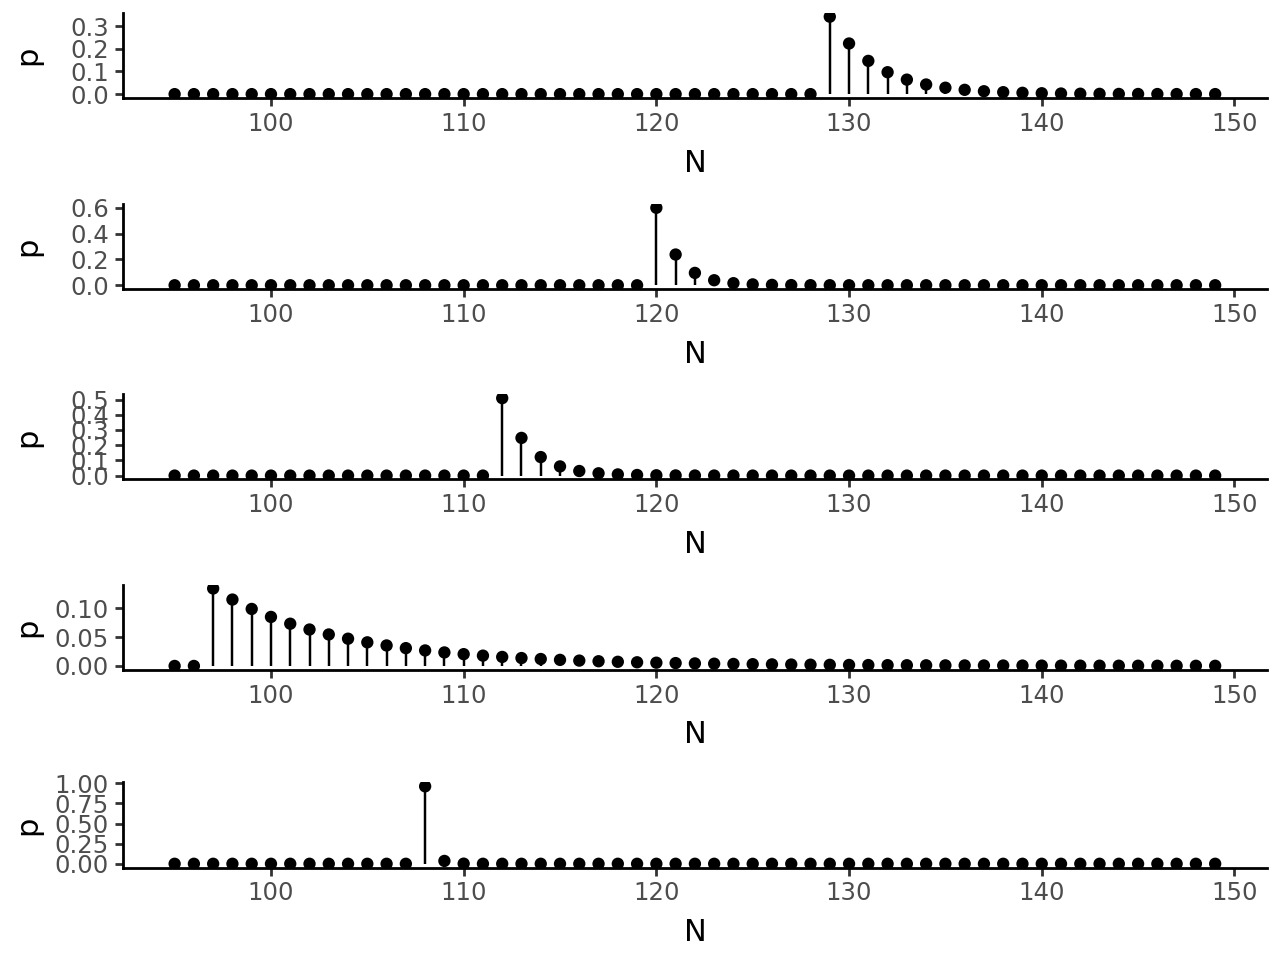

In [267]:

idxs= [i for i in range(95,150)]
r1_p_vals = [dgtp(i,rule_01) for i in idxs]
r2_p_vals = [dgtp(i,rule_02) for i in idxs]
r3_p_vals = [dgtp(i,rule_03) for i in idxs]
r4_p_vals = [dgtp(i,rule_04) for i in idxs]
r5_p_vals = [dgtp(i,rule_05) for i in idxs]
#all_rules_vals = [dgtp(i,all_rules) for i in idxs]

a = pd.DataFrame({"N":idxs,"p":r1_p_vals})
b = pd.DataFrame({"N":idxs,"p":r2_p_vals})
c = pd.DataFrame({"N":idxs,"p":r3_p_vals})
d = pd.DataFrame({"N":idxs,"p":r4_p_vals})
e = pd.DataFrame({"N":idxs,"p":r5_p_vals})
#all_df = pd.DataFrame({"N":idxs,"p":all_rules_vals})

(ggplot(a,aes("N", "p")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "p")) +
  theme_classic()
) / (ggplot(b,aes("N", "p")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "p")) +
  theme_classic()
) / (ggplot(c,aes("N", "p")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "p")) +
  theme_classic()
) / (ggplot(d,aes("N", "p")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "p")) +
  theme_classic()
) / (ggplot(e,aes("N", "p")) +
  geom_point() +
  geom_segment(aes(x = "N", xend = "N", y = 0, yend= "p")) +
  theme_classic()
)

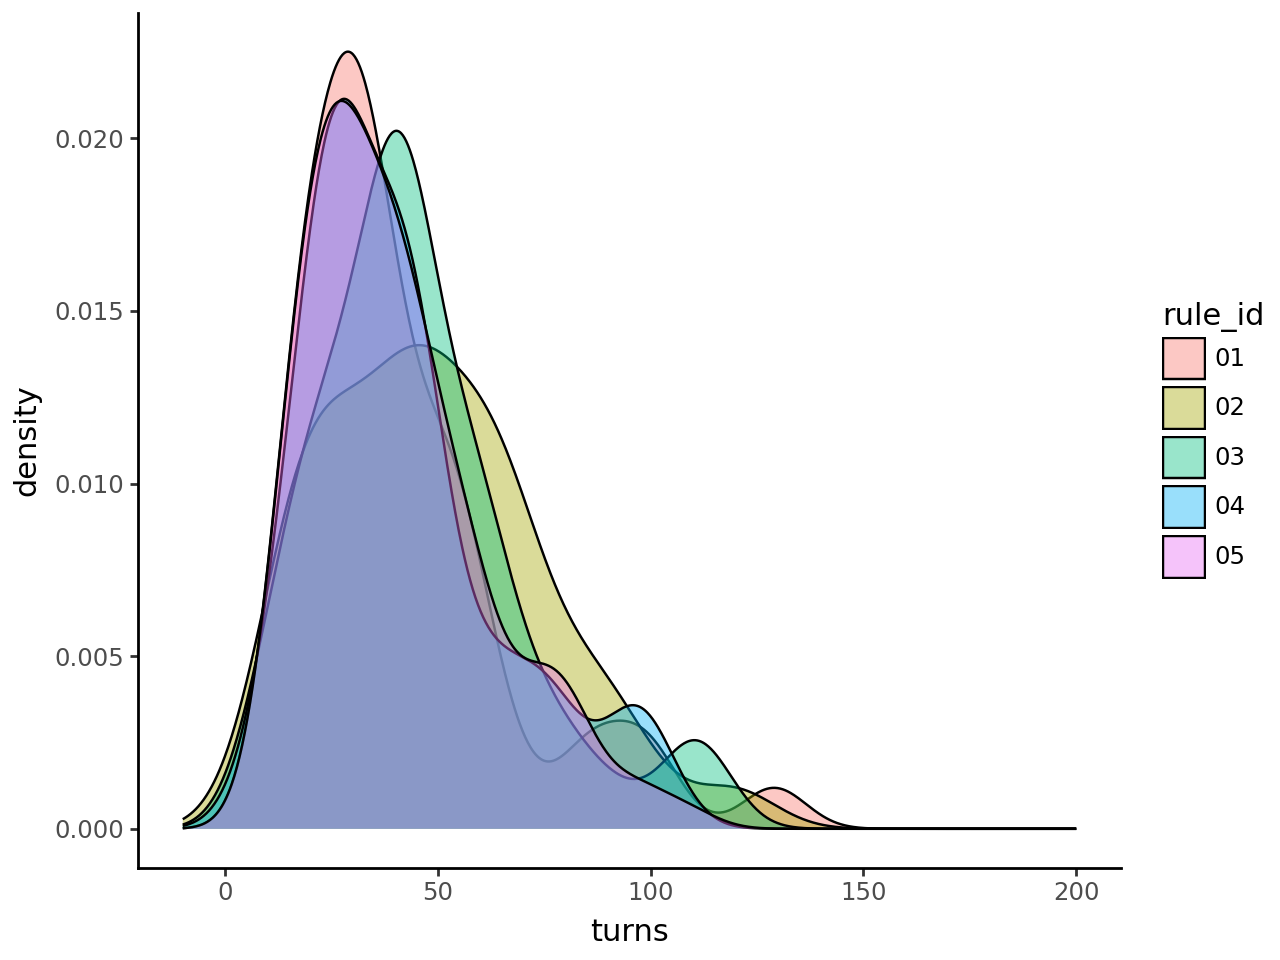

In [279]:
(ggplot(a_wins,aes("turns", fill = "rule_id")) +
  geom_density(alpha = 0.4) +
  scale_x_continuous(limits = [-10,200]) +
  theme_classic()
)

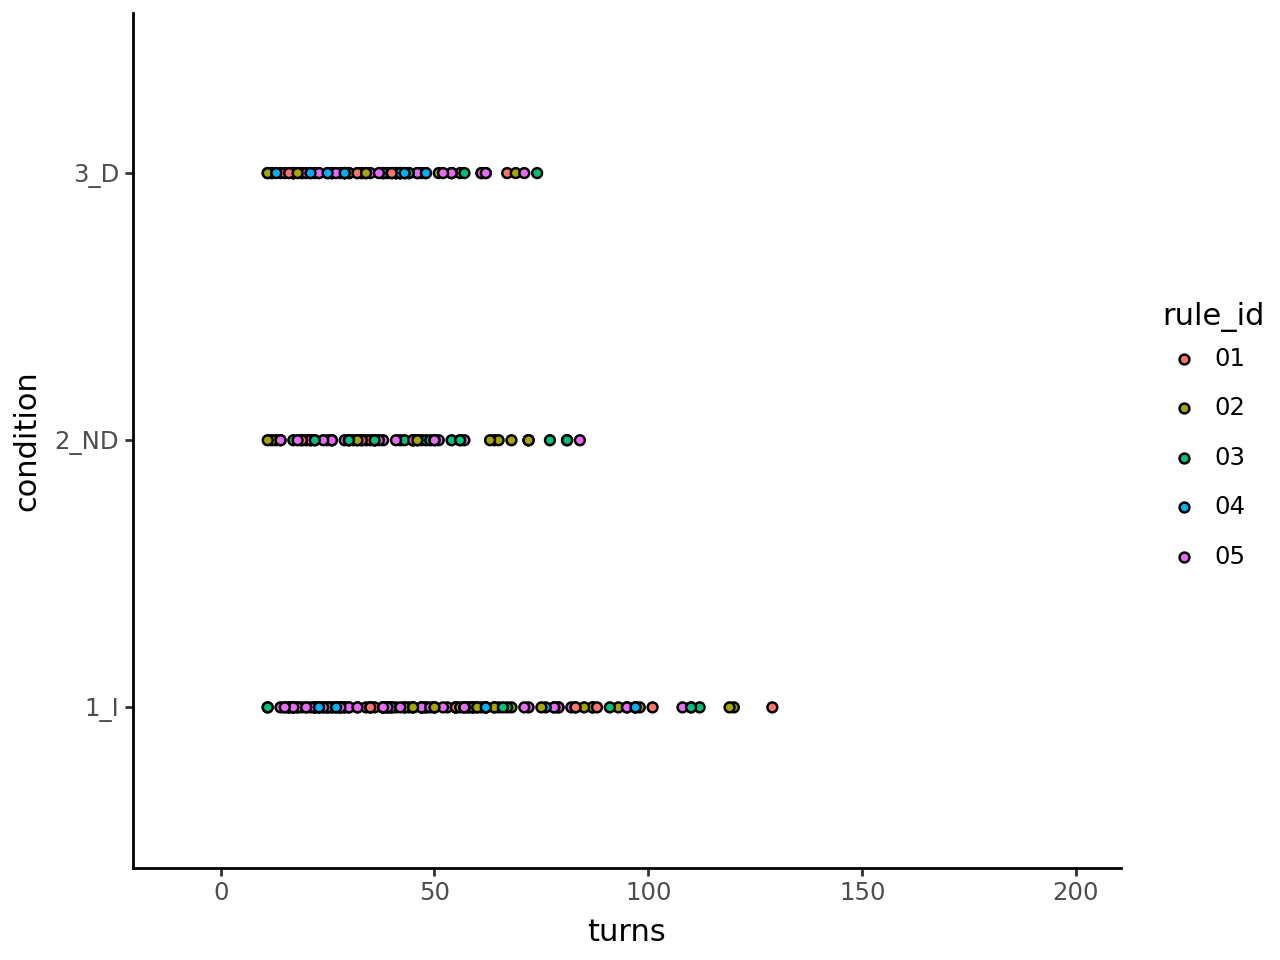

In [299]:
(ggplot(a_wins,aes("turns", "condition", fill = "rule_id")) +
  geom_point() +
  scale_x_continuous(limits = [-10,200]) +
  theme_classic()
)

In [ ]:
#easiest -> 
#what is the chance x came from distribution z

import pymc as pm
import arviz as azs

In [309]:
#data
Y = rule_01

basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    hn_sigma = pm.Uniform("hn_sigma",lower=0, upper=100)
    # Likelihood (sampling distribution) of observations
    Y_obs = pm.HalfNormal("Y_obs", sigma=hn_sigma, observed=Y)
    # draw 1000 posterior samples
    idata = pm.sample()


az.summary(idata, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [hn_sigma]


c:\alien_filter\alien_venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 54 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hn_sigma,49.75,5.4,40.7,60.6,0.14,0.13,1617.02,1726.12,1.0


In [ ]:
ml_model = pm.Model()

with ml_model:
    # Priors for unknown model parameters
    hn_sigma = pm.Uniform("hn_sigma",lower=0, upper=100)
    # Likelihood (sampling distribution) of observations
    Y_obs = pm.HalfNormal("Y_obs", sigma=hn_sigma[rule_id], observed=a_wins)

,unique_id,condition,block,rule_id,rule_num,turns,win
4,1_11_1,1_I,test,01,2,97,1.0
5,1_11_1,1_I,test,01,3,55,1.0
7,1_11_1,1_I,test,01,5,16,1.0
10,1_12_2,1_I,test,02,2,93,1.0
11,1_12_2,1_I,test,02,3,120,1.0
...,...,...,...,...,...,...,...
814,3_7_1,3_D,test,02,6,18,1.0
823,3_9_1,3_D,test,04,2,21,1.0
825,3_9_1,3_D,test,04,4,48,1.0
826,3_9_1,3_D,test,04,5,29,1.0


In [ ]:
coords = {"rule_id":list(a_wins["rule_id"]),
          "turns":list(a_wins["turns"]),
          }

with pm.Model(coords=coords) as unpooled_model:
    # Priors for unknown model parameters
    hn_sigma = pm.Uniform("hn_sigma",lower=0, upper=100,dims="rule_id")
    # Likelihood (sampling distribution) of observations
    observed_turns = pm.HalfNormal("Y_obs", sigma=hn_sigma, observed=(a_wins["turns"]))
    # draw 1000 posterior samples
    idata = pm.sample()


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [hn_sigma]


Output()